# Resonance vs. Integrator Dynamics in the AMAT Model

This notebook investigates and validates the characteristics of Post-Synaptic Currents (PSCs) in resonators versus integrators using the AMAT model. It reproduces the findings, neuronal characteristics, and visual data presented in the Appendix of Yamauchi et al., 2011.

### Difference between integrator vs. resonator PSC behaviour? 
- Integrator Behaviour (All-Pass): Acts like a leaky bucket. It accumulates (sums up) all incoming inputs over time, regardless of their timing. It fires a spike when the total input volume exceeds the threshold. It acts as a low-pass filter, favoring high-frequency bursts or closely packed inputs.
- Resonator Behaviour (Band-Pass): Acts like a swing. It is highly sensitive to the specific **timing** and **frequency** of inputs. It prefers a specific inter-pulse interval ($\Delta$). If a second pulse arrives at the peak of the internal oscillation caused by the first pulse, the system "resonates" and triggers a spike. If the timing is off, the inputs cancel out.

These characteristics which we aim to simulate are displayed in this figure below. 


<img src="images/integrator_resonator.png" width="1050" height="600">

In [10]:
# testing imports and mamba env 
import nest
import pynestml
import sys
import numpy as np
import matplotlib. pyplot as plt 
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils

In [3]:
# importing and building the MAT neuron from nestml, for a conda-forge NEST install, NEST lives directly in the env prefix
nest_path = sys.prefix
print(f"nest root dir: {repr(nest_path)}")   # sanity check, seeing where nest_path is derived from 

module_name, neuron_model_name = NESTCodeGeneratorUtils.generate_code_for(
    "neurons_nestml/amat_neuron.nestml",
    module_name="nestml_amat_module",   # stating the name explicitly
    logging_level="INFO", # INFO or DEBUG amount of debugging output we get from the build 
)
print(f"module: {module_name} loaded")
print(f"neuron model: {neuron_model_name}")

nest root dir: '/Users/angusgray/Desktop/JSC/nest-simulator/mamba'


[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/neurons_nestml/amat_neuron.nestml
[3,GLOBAL, INFO]: Target platform code will be generated in directory: "/Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target"
[4,GLOBAL, INFO]: Target platform code will be installed in directory: "/var/folders/jk/36jftn6s3yz6ks1zj2zdlry40000gn/T/nestml_target_l4zx304r"

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[5,GLOBAL, INFO]: The NEST Simulator version was automatically detected as: main
[6,GLOBAL, INFO]: Given template root path is not an absolute path. Creating the absolute path with default templates direc

INFO:root:Analysing input:
INFO:root:{
    "dynamics": [
        {
            "expression": "V_th_alpha_1' = (-V_th_alpha_1) / tau_1",
            "initial_values": {
                "V_th_alpha_1": "0"
            }
        },
        {
            "expression": "V_th_alpha_2' = (-V_th_alpha_2) / tau_2",
            "initial_values": {
                "V_th_alpha_2": "0"
            }
        },
        {
            "expression": "V_m' = ((-(V_m - E_L)) / tau_m + ((unit_psc * (I_kernel_exc__X__exc_spikes - I_kernel_inh__X__inh_spikes)) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "V_th_v_aux' = (-V_th_v_aux) / tau_V + beta * ((-(V_m - E_L)) / tau_m + ((unit_psc * (I_kernel_exc__X__exc_spikes - I_kernel_inh__X__inh_spikes)) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_th_v_aux": "0 / 1.0"
            }
        },
        {
            "expression": "V_t

[11,GLOBAL, INFO]: Starting code generation for model "amat_neuron_nestml"
[12,amat_neuron_nestml, INFO, [124:0;231:0]]: Starts processing of the model "amat_neuron_nestml"
[13,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/amat_neuron_nestml.cpp
[14,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/amat_neuron_nestml.h
[15,amat_neuron_nestml, INFO, [124:0;231:0]]: Successfully generated code for the model: "amat_neuron_nestml" in: "/Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target" !
[16,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/CMakeLists.txt
[17,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/nestml_amat_module.h
[18,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/nestml_amat_module.cpp
[19,GLOBAL, IN

### Creating and Running a simple Integrator/Resonator NEST Simulation (Spike Trains)

To change the model from an integrator to a resonator, we manipulate the threshold dynamics equation. In the AMAT model, the subthreshold adaptation is governed by the parameters $\alpha$, $\beta$, and their respective time constants $\tau$. The behavior is mapped out using two dimensionless parameters:
- Time-constant ratio: $\gamma = \frac{\tau_\beta}{\tau_m}$
- Adaptation strength: $B = \beta \tau_m$


Which then can be re-arranged to ... 

- Time-constant ratio: $\tau_\beta = {\gamma}{\tau_m}$
- Adaptation strength: $\beta  = \frac{B}{tau_m}$

Where 
- $\tau_m$ is a membrane time constant
-  $\tau_\beta$ is the time constant of the adaptation variable 
-   $\beta$ is a constant in the voltage dependency term (manipulating the neurons response, positive or negative feedback)

When these parameters are tuned into the **Resonator Zone**, the adaptive threshold $\theta(t)$ tracks the membrane potential $V(t)$ in a way that creates a temporary "hyper-excitable window" at a specific time delay ($\Delta$). 

The quantity we will be plotting instead of V_m it will be the distance between the membrane potential and the adaptive threshold (V(t) - theta(t)) 

- If V-theta > 0, the neuron spikes
- If V-theta < 0, the neuron does not spike.

Is neuron loaded: True
AMAT Neuronal characteristics: dict_keys(['C_m', 'Ca', 'E_L', 'I_e', 'I_kernel_exc__X__exc_spikes', 'I_kernel_inh__X__inh_spikes', 'V_m', 'V_th_alpha_1', 'V_th_alpha_2', 'V_th_v', 'V_th_v_aux', '__P__I_kernel_exc__X__exc_spikes__I_kernel_exc__X__exc_spikes', '__P__I_kernel_inh__X__inh_spikes__I_kernel_inh__X__inh_spikes', '__P__V_m__I_kernel_exc__X__exc_spikes', '__P__V_m__I_kernel_inh__X__inh_spikes', '__P__V_m__V_m', '__P__V_th_alpha_1__V_th_alpha_1', '__P__V_th_alpha_2__V_th_alpha_2', '__P__refr_t__refr_t', '__h', 'alpha_1', 'alpha_2', 'available', 'beta', 'beta_Ca', 'capacity', 'element_type', 'elementsize', 'frozen', 'global_id', 'gsl_abs_error_tol', 'gsl_rel_error_tol', 'instantiations', 'local', 'model', 'model_id', 'node_uses_wfr', 'omega', 'recordables', 'refr_T', 'refr_t', 'synaptic_elements', 'tau_1', 'tau_2', 'tau_Ca', 'tau_V', 'tau_m', 'tau_syn_exc', 'tau_syn_inh', 'thread', 'thread_local_id', 'type_id', 'unit_psc', 'vp'])
[INFO] Default tau_m = 10.0

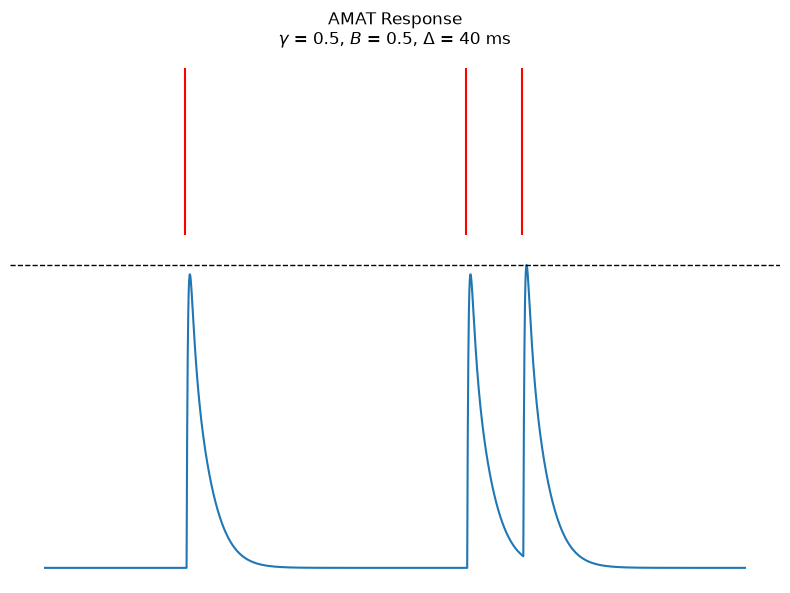

In [70]:
# Reset the NEST kernel to a completely clean state.
nest.ResetKernel()

# Only display errors from NEST (suppresses warnings and info messages).
nest.set_verbosity("M_ERROR")

# Configure parameters for the simulation kernel.
nest.SetKernelStatus({"resolution": 0.1, "local_num_threads": 1, "rng_seed": 12345})

# Load the compiled custom neuron module (.so library), available to nest.
nest.Install(module_name)
print("Is neuron loaded:", neuron_model_name in nest.node_models)  # nest.Models() is deprecated

defaults = nest.GetDefaults(neuron_model_name)
print(f"AMAT Neuronal characteristics: {defaults.keys()}")

# extracting and printing out neuronal parameters we are interested in 
tau_m = defaults["tau_m"]
print(f"[INFO] Default tau_m = {tau_m:.2f} ms")

# defining dimensionless parameters 
gamma = 0.5
B = 0.5
omega = 5.0

# defining equation for time-constant ratio
tau_beta = gamma * tau_m

# defining equation for adaptation strength 
beta = B / tau_m

print(f"[INFO] Time constant ratio gamma = {gamma}")
print(f"[INFO] Adaptation strength B = {B}")

print(f"[INFO] tau_beta = {tau_beta:.2f} ms")
print(f"[INFO] beta = {beta:.4f}")


neuron = nest.Create(
    neuron_model_name,
    params={
        "omega": 5.0,
        "alpha_1": 10.0,
        "alpha_2": 0.0,

        # converted parameter
        "beta": beta,

        # adaptation time constant
        "tau_1": tau_beta,
    },
)


# Choose inter-pulse interval (ms)
delta = 40      # Try 5, 10, 20, 40, 60, 80 ...
initial_spike = 100.0
start_pulse = 300.0

spike_times = [
    initial_spike,
    start_pulse,
    start_pulse + delta
]

spike_generator = nest.Create(
    "spike_generator",
    params={
        "spike_times": spike_times
    }
)

# Connect
nest.Connect(
    spike_generator,
    neuron,
    syn_spec={
        "weight":1.0,
        "delay":1.0
    }
)

# Record PSCs
multimeter = nest.Create(
    "multimeter",
    params={
        "interval":0.1,
        "record_from":[
            "V_m",
            "V_th_alpha_1",
            "V_th_alpha_2",
            "V_th_v",
            "I_kernel_exc__X__exc_spikes",
            
        ]
    }
)



nest.Connect(
    multimeter,
    neuron
)

# Simulate
nest.Simulate(500)

# Plot
data = multimeter.events
t = data["times"]
psc = data["I_kernel_exc__X__exc_spikes"]
vm = data["V_m"]


theta = (
    omega
    + data["V_th_alpha_1"]
    + data["V_th_alpha_2"]
    + data["V_th_v"]
)

distance = data["V_m"] - theta
peak = np.max(distance)



fig, ax = plt.subplots(
    2, 1,
    figsize=(8,6),
    sharex=True,
    gridspec_kw={"height_ratios":[1,2]}
)


# -----------------------------
# Input spikes
# -----------------------------

for spike in spike_times:
    ax[0].vlines(
        spike,
        0,
        1,
        linewidth=1.5,
        color="red"
    )

ax[0].set_ylim(0,1)
ax[0].axis("off")

# -----------------------------
# AMAT membrane response
# -----------------------------

ax[1].plot(
    t,
    distance,
    linewidth=1.5
)
ax[1].axhline(
    peak,
    linestyle="--",
    color="black",
    linewidth=1
)

ax[1].axis("off")


plt.suptitle(
    f"AMAT Response\n"
    f"$\\gamma$ = {gamma}, "
    f"$B$ = {B}, "
    f"$\\Delta$ = {delta} ms",
    fontsize=12,
)

plt.tight_layout()

plt.show()

# AMAT Time-Constant and Adaptation Strength Sweep 